<a href="https://colab.research.google.com/github/vaibhavkatex/Titanic-Survival/blob/main/titanic_survival.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Titanic Machine Learning Model Using a Logistic Regression Model**

In [35]:

# IMPORT LIBRARIES

import numpy as np                    # Mathematical & Array Operations
import pandas as pd                   # Tabular Data & CSV Handling
import matplotlib.pyplot as plt       # Basic Graph Visualization
import seaborn as sns                 # Advanced Statistical Charts

from sklearn.model_selection import train_test_split   # Dataset Splitting
from sklearn.preprocessing import StandardScaler        # Feature Scaling
from sklearn.preprocessing import LabelEncoder          # Categorical Encoding

from sklearn.linear_model import LogisticRegression    # ML Algorithm
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report # Evaluation

import joblib                          # Model Persistence (Save/Load)

In [36]:
from google.colab import files
Uploaded = files.upload()

Saving Titanic.csv to Titanic (1).csv


In [37]:
df = pd.read_csv("Titanic.csv")

In [38]:
# Load a Dataset
df

,Passengerid,Age,Fare,Sex,sibsp,zero,zero.1,zero.2,zero.3,zero.4,...,zero.12,zero.13,zero.14,Pclass,zero.15,zero.16,Embarked,zero.17,zero.18,2urvived
0,1,22.0,7.2500,0,1,0,0,0,0,0,...,0,0,0,3,0,0,2.0,0,0,0
1,2,38.0,71.2833,1,1,0,0,0,0,0,...,0,0,0,1,0,0,0.0,0,0,1
2,3,26.0,7.9250,1,0,0,0,0,0,0,...,0,0,0,3,0,0,2.0,0,0,1
3,4,35.0,53.1000,1,1,0,0,0,0,0,...,0,0,0,1,0,0,2.0,0,0,1
4,5,35.0,8.0500,0,0,0,0,0,0,0,...,0,0,0,3,0,0,2.0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1304,1305,28.0,8.0500,0,0,0,0,0,0,0,...,0,0,0,3,0,0,2.0,0,0,0
1305,1306,39.0,108.9000,1,0,0,0,0,0,0,...,0,0,0,1,0,0,0.0,0,0,0
1306,1307,38.5,7.2500,0,0,0,0,0,0,0,...,0,0,0,3,0,0,2.0,0,0,0
1307,1308,28.0,8.0500,0,0,0,0,0,0,0,...,0,0,0,3,0,0,2.0,0,0,0


In [39]:
df.head()

,Passengerid,Age,Fare,Sex,sibsp,zero,zero.1,zero.2,zero.3,zero.4,...,zero.12,zero.13,zero.14,Pclass,zero.15,zero.16,Embarked,zero.17,zero.18,2urvived
0,1,22.0,7.2500,0,1,0,0,0,0,0,...,0,0,0,3,0,0,2.0,0,0,0
1,2,38.0,71.2833,1,1,0,0,0,0,0,...,0,0,0,1,0,0,0.0,0,0,1
2,3,26.0,7.9250,1,0,0,0,0,0,0,...,0,0,0,3,0,0,2.0,0,0,1
3,4,35.0,53.1000,1,1,0,0,0,0,0,...,0,0,0,1,0,0,2.0,0,0,1
4,5,35.0,8.0500,0,0,0,0,0,0,0,...,0,0,0,3,0,0,2.0,0,0,0


In [40]:
df.tail()

,Passengerid,Age,Fare,Sex,sibsp,zero,zero.1,zero.2,zero.3,zero.4,...,zero.12,zero.13,zero.14,Pclass,zero.15,zero.16,Embarked,zero.17,zero.18,2urvived
1304,1305,28.0,8.0500,0,0,0,0,0,0,0,...,0,0,0,3,0,0,2.0,0,0,0
1305,1306,39.0,108.9000,1,0,0,0,0,0,0,...,0,0,0,1,0,0,0.0,0,0,0
1306,1307,38.5,7.2500,0,0,0,0,0,0,0,...,0,0,0,3,0,0,2.0,0,0,0
1307,1308,28.0,8.0500,0,0,0,0,0,0,0,...,0,0,0,3,0,0,2.0,0,0,0
1308,1309,28.0,22.3583,0,1,0,0,0,0,0,...,0,0,0,3,0,0,0.0,0,0,0


In [41]:
# Dataset Shape
df.shape

(1309, 28)

In [42]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 28 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Passengerid  1309 non-null   int64  
 1   Age          1309 non-null   float64
 2   Fare         1309 non-null   float64
 3   Sex          1309 non-null   int64  
 4   sibsp        1309 non-null   int64  
 5   zero         1309 non-null   int64  
 6   zero.1       1309 non-null   int64  
 7   zero.2       1309 non-null   int64  
 8   zero.3       1309 non-null   int64  
 9   zero.4       1309 non-null   int64  
 10  zero.5       1309 non-null   int64  
 11  zero.6       1309 non-null   int64  
 12  Parch        1309 non-null   int64  
 13  zero.7       1309 non-null   int64  
 14  zero.8       1309 non-null   int64  
 15  zero.9       1309 non-null   int64  
 16  zero.10      1309 non-null   int64  
 17  zero.11      1309 non-null   int64  
 18  zero.12      1309 non-null   int64  
 19  zero.1

In [43]:
df.describe()

,Passengerid,Age,Fare,Sex,sibsp,zero,zero.1,zero.2,zero.3,zero.4,...,zero.12,zero.13,zero.14,Pclass,zero.15,zero.16,Embarked,zero.17,zero.18,2urvived
count,1309.000000,1309.000000,1309.000000,1309.000000,1309.000000,1309.0,1309.0,1309.0,1309.0,1309.0,...,1309.0,1309.0,1309.0,1309.000000,1309.0,1309.0,1307.000000,1309.0,1309.0,1309.000000
mean,655.000000,29.503186,33.281086,0.355997,0.498854,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,2.294882,0.0,0.0,1.492731,0.0,0.0,0.261268
std,378.020061,12.905241,51.741500,0.478997,1.041658,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.837836,0.0,0.0,0.814626,0.0,0.0,0.439494
min,1.000000,0.170000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.000000,0.0,0.0,0.000000,0.0,0.0,0.000000
25%,328.000000,22.000000,7.895800,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,2.000000,0.0,0.0,1.000000,0.0,0.0,0.000000
50%,655.000000,28.000000,14.454200,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,3.000000,0.0,0.0,2.000000,0.0,0.0,0.000000
75%,982.000000,35.000000,31.275000,1.000000,1.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,3.000000,0.0,0.0,2.000000,0.0,0.0,1.000000
max,1309.000000,80.000000,512.329200,1.000000,8.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,3.000000,0.0,0.0,2.000000,0.0,0.0,1.000000


In [44]:
# all Dataset Columns Name
df.columns

Index(['Passengerid', 'Age', 'Fare', 'Sex', 'sibsp', 'zero', 'zero.1',
       'zero.2', 'zero.3', 'zero.4', 'zero.5', 'zero.6', 'Parch', 'zero.7',
       'zero.8', 'zero.9', 'zero.10', 'zero.11', 'zero.12', 'zero.13',
       'zero.14', 'Pclass', 'zero.15', 'zero.16', 'Embarked', 'zero.17',
       'zero.18', '2urvived'],
      dtype='object')

In [45]:
# Deleting a unessaary Columns
df = df.drop(columns=df.filter(like="zero").columns)

In [46]:
df

,Passengerid,Age,Fare,Sex,sibsp,Parch,Pclass,Embarked,2urvived
0,1,22.0,7.2500,0,1,0,3,2.0,0
1,2,38.0,71.2833,1,1,0,1,0.0,1
2,3,26.0,7.9250,1,0,0,3,2.0,1
3,4,35.0,53.1000,1,1,0,1,2.0,1
4,5,35.0,8.0500,0,0,0,3,2.0,0
...,...,...,...,...,...,...,...,...,...
1304,1305,28.0,8.0500,0,0,0,3,2.0,0
1305,1306,39.0,108.9000,1,0,0,1,0.0,0
1306,1307,38.5,7.2500,0,0,0,3,2.0,0
1307,1308,28.0,8.0500,0,0,0,3,2.0,0


In [47]:
df.columns

Index(['Passengerid', 'Age', 'Fare', 'Sex', 'sibsp', 'Parch', 'Pclass',
       'Embarked', '2urvived'],
      dtype='object')

In [48]:
df.rename(columns={"Passengerid": "PassengerID"}, inplace=True)
df.rename(columns={"Fare": "Ticket Price"}, inplace=True)
df.rename(columns={"sibsp": "Siblings"}, inplace=True)
df.rename(columns={"2urvived": "Survived"}, inplace=True)

In [49]:
df.columns

Index(['PassengerID', 'Age', 'Ticket Price', 'Sex', 'Siblings', 'Parch',
       'Pclass', 'Embarked', 'Survived'],
      dtype='object')

In [50]:
df.dtypes

,0
PassengerID,int64
Age,float64
Ticket Price,float64
Sex,int64
Siblings,int64
Parch,int64
Pclass,int64
Embarked,float64
Survived,int64


In [51]:
df.isnull().sum()

,0
PassengerID,0
Age,0
Ticket Price,0
Sex,0
Siblings,0
Parch,0
Pclass,0
Embarked,2
Survived,0


In [52]:
df = df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

In [53]:
df.isnull().sum()

np.int64(0)

In [54]:
df = pd.read_csv("Titanic.csv")
df = df.drop(columns=df.filter(like="zero").columns)
df.rename(columns={
    "Passengerid": "PassengerID",
    "Fare": "Ticket Price",
    "sibsp": "Siblings",
    "2urvived": "Survived"
}, inplace=True)
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])
df.columns

Index(['PassengerID', 'Age', 'Ticket Price', 'Sex', 'Siblings', 'Parch',
       'Pclass', 'Embarked', 'Survived'],
      dtype='object')

In [55]:
df.drop_duplicates(inplace=True)

In [56]:
df.duplicated().sum()

np.int64(0)

**EDA**

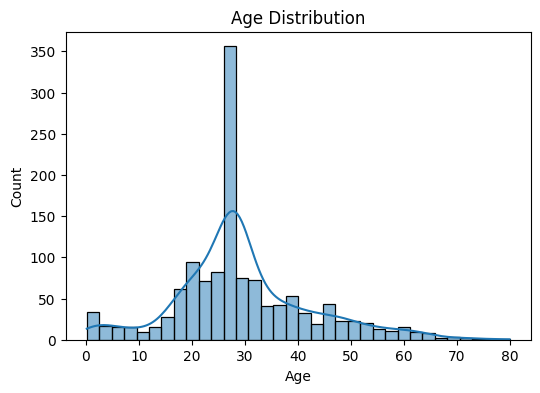

In [57]:
# 1. Distribution Check (Histogram / KDE)
plt.figure(figsize=(6, 4))
sns.histplot(df["Age"], kde=True)
plt.title("Age Distribution")
plt.show()

**Separate Features**

In [58]:

X = df.drop("Survived", axis=1)
y = df["Survived"]

**One-Hot Encoding**

In [59]:
# One-Hot Encoding for Unordered Categorical Features in X
X = pd.get_dummies(X, drop_first=True, dtype=int)

**Train-Test Split**

In [60]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

**Feature Scaling**

In [68]:
scaler = StandardScaler()

# Train data par Learn (fit) + Scale (transform)
X_train = scaler.fit_transform(X_train)

# Test data par ONLY Scale (transform) - Kabhi test data par fit() mat karna!
X_test = scaler.transform(X_test)

In [70]:
from sklearn.linear_model import LogisticRegression
import joblib

model = LogisticRegression()
model.fit(X_train, y_train)

joblib.dump(model, "model.pkl")

print("Model saved successfully!")

Model saved successfully!


**Build Model Object**

In [71]:
# Logistic Regression Classifier Create Karna
model = LogisticRegression(max_iter=1000, random_state=42)

**Train Model**

In [72]:
# Model Training (Machine is actually learning here!)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000, random_state=42)

**Prediction**

In [73]:
# 1. Binary / Class Predictions (Outputs 0 or 1)
y_pred = model.predict(X_test)

# 2. Probability Predictions (Outputs confidence score for each class)
y_prob = model.predict_proba(X_test)

**Model Evaluation**

In [74]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# 1. Overall Accuracy
acc = accuracy_score(y_test, y_pred)
print(f"Accuracy Score: {acc * 100:.2f}%")

# 2. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

# 3. Complete Detailed Classification Report
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy Score: 84.35%
Confusion Matrix:
 [[177  12]
 [ 29  44]]

Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.94      0.90       189
           1       0.79      0.60      0.68        73

    accuracy                           0.84       262
   macro avg       0.82      0.77      0.79       262
weighted avg       0.84      0.84      0.84       262



**Save Model (`joblib`)**



In [66]:
# Save Files for Production
joblib.dump(model, "model.pkl")
joblib.dump(scaler, "scaler.pkl")
joblib.dump(X.columns.tolist(), "columns.pkl")

print("Model & Pipeline components successfully saved!")

Model & Pipeline components successfully saved!


**Loading a Model**

In [67]:
# Loading Model Future Usage Me:
loaded_model = joblib.load("model.pkl")
loaded_scaler = joblib.load("scaler.pkl")
loaded_columns = joblib.load("columns.pkl")